In [3]:
import pandas as pd
from pathlib import Path
import os
from helpers.load import *
from helpers.select_scenario import *

scenario_folder_lake = select_scenario("lake", True)
scenario_folder_soil = select_scenario("soil", True)

node_pos_df_lake = load_node_pos_df(scenario_folder_lake)
node_pos_df_soil = load_node_pos_df(scenario_folder_soil)

Selected scenario: lake

Selected run: 2025-03-05_14:27
Selected scenario: soil

Selected run: 2025-03-05_09:45


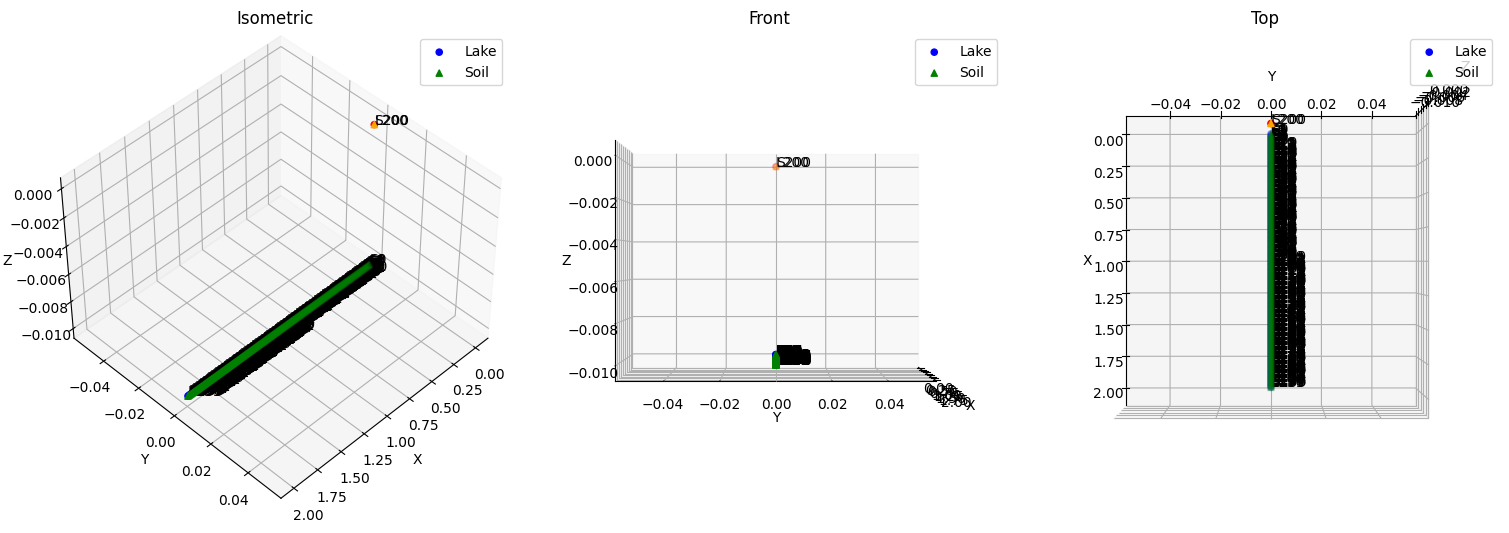

In [4]:
# Plot a 3D graph using the x, y, z coordinates. Color the nodes based on type.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Map 'Type' to colors for each scenario
color_map_lake = {'AP': 'red', 'STA': 'blue'}
color_map_soil = {'AP': 'orange', 'STA': 'green'}

colors_lake = node_pos_df_lake['NodeType'].map(color_map_lake)
colors_soil = node_pos_df_soil['NodeType'].map(color_map_soil)

fig = plt.figure(figsize=(15, 5))

# Create 3 subplots showing different viewing angles
angles = [(45, 45), (0, 0), (90, 0)]
titles = ['Isometric', 'Front', 'Top']

for i, (elev, azim) in enumerate(angles, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    # Plot lake scenario nodes
    ax.scatter(node_pos_df_lake['X'], node_pos_df_lake['Y'], node_pos_df_lake['Z'], 
              c=colors_lake, marker='o', label='Lake')
    
    # Plot soil scenario nodes
    ax.scatter(node_pos_df_soil['X'], node_pos_df_soil['Y'], node_pos_df_soil['Z'], 
              c=colors_soil, marker='^', label='Soil')
    
    # Add node labels
    for _, row in node_pos_df_lake.iterrows():
        ax.text(row['X'], row['Y'], row['Z'], f'L{row["NodeId"]}')
    for _, row in node_pos_df_soil.iterrows():
        ax.text(row['X'], row['Y'], row['Z'], f'S{row["NodeId"]}')
    
    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(titles[i-1])
    
    # Set labels and legend
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()

plt.tight_layout()
plt.show()